# An Application of Machine Learning in Startup Investments 

Startup investment can be very risky due to the high failure rate of startups. To assist startup investors with their decisions, in this project we aim to find the important features that lead to startup success and forecast a company’s success with supervised machine learning methods. 


# Table of Contents:

1) Cleaning Data
2) Exploratory Data Analysis 
3) Featured Engineering 
4) Constructing 3 Dataframes for Training Models
5) Model Training and Predictions - Each model is trained with the default parameters and then with tuned parameters 

### Data

To train the machine learning model, we used investment data about startup companies available on Kaggle. The data has been collected from Crunchbase which is a leading website for company insights from early stage startups to Fortune 1000. 

The data has around 54k rows and 39 columns. It has company information such as name of the company, url, market, country, state, region, city, founded date, first funding date, last funding date. It also had data on different investment types such as seed, venture equity crowdfunding, undisclosed funding, convertible note, debt financing, angel, grant, private equity, post ipo equity, post ipo debt, secondary market, product crowdfunding, round A-H series funding. Detailed descriptions of the different funding types is available. Status of the companies were also available and categorized as acquired, operating and closed.


Sources - The notebook is mostly borrows from https://www.kaggle.com/code/pball01/predicting-startup-success. 

The Notebook has been transformed to use Snowpark ML models to demonstrate the use fo ML in Snowflake - this is the purpose of the project. This improved speed significantly and metric preformance as well. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# import graphviz

from pydot import graph_from_dot_data
import pydot
import random



In [2]:
#*#*#* Snowpark for Python

from snowflake.snowpark import Session
from snowflake.snowpark.version import VERSION
from snowflake.snowpark.types import StructType, StructField, DoubleType, StringType
import snowflake.snowpark.functions as F
import json
from snowflake.snowpark.context import get_active_session

session = get_active_session()


Connection Established with the following parameters:
User                        : MSAL
Role                        : "ACCOUNTADMIN"
Database                    : "VC_DB"
Schema                      : "DEMO_VC"
Warehouse                   : "COMPUTE_VC"
Snowflake version           : 8.22.1
Snowpark for Python version : 1.14.0


### Uploading the dataset

In [3]:
input_tbl = f"{session.get_current_database()}.TABLES.{'VC_RAW'}"

VCdf = session.table(input_tbl)

df = VCdf.to_pandas()

column_mapping = { 'PERMALINK': 'permalink', 'NAME': 'name', 'HOMEPAGE_URL': 'homepage_url', 'CATEGORY_LIST': 'category_list','MARKET': 'market', 'FUNDING_TOTAL_USD': 'funding_total_usd','STATUS': 'status', 'COUNTRY_CODE': 'country_code','STATE_CODE': 'state_code', 'REGION': 'region', 'CITY': 'city','FUNDING_ROUNDS': 'funding_rounds', 'FOUNDED_AT': 'founded_at','FOUNDED_MONTH': 'founded_month','FOUNDED_QUARTER': 'founded_quarter',
    'FOUNDED_YEAR': 'founded_year','FIRST_FUNDING_AT': 'first_funding_at','LAST_FUNDING_AT': 'last_funding_at','SEED': 'seed','VENTURE': 'venture','EQUITY_CROWDFUNDING': 'equity_crowdfunding','UNDISCLOSED': 'undisclosed','CONVERTIBLE_NOTE': 'convertible_note','DEBT_FINANCING': 'debt_financing','ANGEL': 'angel','GRANT': 'grant','PRIVATE_EQUITY': 'private_equity','POST_IPO_EQUITY': 'post_ipo_equity', 'POST_IPO_DEBT': 'post_ipo_debt', 'SECONDARY_MARKET': 'secondary_market','PRODUCT_CROWDFUNDING': 'product_crowdfunding','ROUND_A': 'round_A','ROUND_B': 'round_B','ROUND_C': 'round_C','ROUND_D': 'round_D','ROUND_E': 'round_E','ROUND_F': 'round_F','ROUND_G': 'round_G','ROUND_H': 'round_H'
}

df.rename(columns=column_mapping, inplace=True)


In [4]:
pd.set_option('display.max_columns', None)
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06,2012-Q2,2012.0,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,Los Angeles,2.0,None,None,None,NaN,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,None,Tallinn,Tallinn,1.0,2012-10-26,2012-10,2012-Q4,2012.0,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,None,London,London,1.0,2011-04-01,2011-04,2011-Q2,2011.0,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,None,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,Fort Worth,2.0,2014-01-01,2014-01,2014-Q1,2014.0,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()# date is not being read properly as 'date' datatype & some numerical values like funding_total_usd is being read as a object

#df['round_H'].describe()['mean']

14231.967312593551

## Cleaning Data

To clean the data, we removed extra spaces from different columns and also removed things like “ , ”, “ - ” where ever necessary. We made sure that columns that had numbers were being read as numbers and also converted all of the date columns into date data types.

Rows with null values were removed. Columns with a high percentage of null values like state, city, region, and found date were removed. 


In [6]:
# clean and convert data types for specific columns
df = df.rename(columns={' market ': "market", ' funding_total_usd ': "funding_total_usd"})

df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')
df['funding_total_usd'] = df['funding_total_usd'].str.replace(' ', '')
df['funding_total_usd'] = df['funding_total_usd'].str.replace('-', '0')
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'])

df['founded_at'] = pd.to_datetime(df['founded_at'], format='%Y-%m-%d', errors='coerce')
df['first_funding_at'] = pd.to_datetime(df['first_funding_at'], format='%Y-%m-%d', errors='coerce')
df['last_funding_at'] = pd.to_datetime(df['last_funding_at'], format='%Y-%m-%d', errors='coerce')
df['founded_year'] = pd.to_datetime(df['founded_year'], format='%Y', errors='coerce')
df['founded_month'] = pd.to_datetime(df['founded_month'], format='%Y-%m', errors='coerce')

df.market = df.market.str.strip()

df.head()


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1.0,2012-06-01,2012-06-01,2012-Q2,2012-01-01,2012-06-30,2012-06-30,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2.0,NaT,NaT,None,NaT,2010-06-04,2010-09-23,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,40000.0,operating,EST,None,Tallinn,Tallinn,1.0,2012-10-26,2012-10-01,2012-Q4,2012-01-01,2012-08-09,2012-08-09,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,None,London,London,1.0,2011-04-01,2011-04-01,2011-Q2,2011-01-01,2011-04-01,2011-04-01,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,None,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,Fort Worth,2.0,2014-01-01,2014-01-01,2014-Q1,2014-01-01,2014-08-17,2014-09-26,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Exploratory Data Analysis

The analysis below is used to understand what information is important for the final model. It also helped us understand the data more before using them in the models. 

Most of the companies were in the Software and Biotechnology industry. Biotechnology had the highest number in total funding. Mobile companies had the second lowest number in total funding. 

A lot of the companies raised venture and seed funding. The number of companies decreased as the companies proceeded to more series funding. Round G and H have a very low number of companies compared to round A and round B.

Most of the acquired and operating companies are from the U.S. Acquired companies had higher mean and median funding compared to closed and operating companies. Acquired companies also had more number of funding rounds compared to companies with closed and operating statuses.

2014 was the latest year and the oldest year was 1902. Most of the companies were founded around the 2000. 

In [7]:
#*#*# NOTICE - UN-COMMENT TO VIEW summary statistics below

#df.count() #no. of values in each column 
#df.nunique() # finding out unique values for each column ## permalink has the highest number of unique values, this is agood indicator that it would good to use it as a unique ID

df['status'].unique() #unique values in status column #status column have three different values, this is what we are going to use to predict against in the ML models

df.groupby('status')['name'].nunique().sort_values(ascending= False) #number of companies with each status type #a lot of 'operating' values in the dataset

#df.groupby('country_code')['name'].nunique().sort_values(ascending=False).head(50) #number of companies in each country_code # most of the values are from USA 

#df.isnull().sum()/df.count() *100 #percentage of null values in each column #around 40% of the data does not have a founded date.  #City, region, state have high number of null values so it would be good to leave these columns.



status
operating    41762
acquired      3691
closed        2603
Name: name, dtype: int64

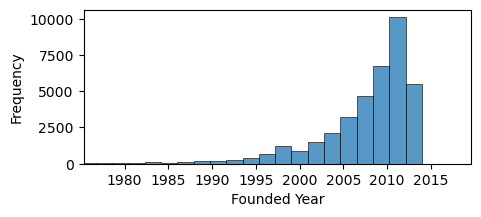

In [8]:


plt.figure(figsize= (5,2))
sns.histplot(data = df['founded_year'], bins = 60)

plt.xlim(1940)
#plt.title('Founded Year')
plt.xlabel('Founded Year')
plt.ylabel('Frequency')

plt.show()


In [9]:
print(df['founded_year'].max()) #newest year #2014 is the newest year
print(df['founded_year'].min()) # oldest year #1902 is the oldest year
print(df['market'].nunique()) # 736 unique number of market

df.groupby('market')['funding_total_usd'].sum().sort_values(ascending = False).head(3)#top 5  markets with the most funding

df.groupby('market')['name'].count().sort_values(ascending = False).head() #Top five markets in terms of count

2014-01-01 00:00:00
1902-01-01 00:00:00
753


market
Software         4620
Biotechnology    3688
Mobile           1983
E-Commerce       1805
Curated Web      1655
Name: name, dtype: int64

# Featured Engineering

We created a new column that included differences in time between the last and first funding date. 

A total investment column was also created that included the sum of all the investments (seed, venture, equity crowdfunding, undisclosed, convertible note, debt financing, angel, grant, private equity, post ipo equity, post ipo debt, secondary market, product crowdfunding).

The data contained 753 different market values. As there were a lot of different types of markets, we wanted to reduce this number. To reduce the number of markets, we grouped markets into different industry groups segment on the industry grouping list produced by crunchbase. 

The data contained 115 countries - we made a new column where countires are replaced with continents. 

Numerical values like total investment, difference in funding year, funding rounds, seed, venture were turned into categories like low and high based on their spread in number. The categorical values were again turned into numbers for the models to understand.

Other columns like equity crowdfunding, undisclosed, convertible note, debt financing, angel, private equity, post ipo equity, secondary market, product crowdfunding, round A -H were turned into 0 and 1 based on if the company was able to raise that type of funding. This was done to improve the Ml model fit - for columns for many zeros this can make it easirer to establish correlations between different parameters. 

In [10]:
df['diff_funding'] = df['last_funding_at'] - df['first_funding_at'] # finding the difference in days between first and last funding dates #subtracts dates and returns the value in days!

df['diff_funding_months'] = (df['last_funding_at'] - df['first_funding_at'])/30 # turning the difference into months

df['total_investment'] = df['seed'] + df['venture'] + df['equity_crowdfunding'] + df['undisclosed'] + df['convertible_note'] + df['debt_financing'] + df['angel'] + df['grant'] + df['private_equity'] + df['post_ipo_equity'] + df['post_ipo_debt'] + df['secondary_market'] + df['product_crowdfunding']

df['diff_first_funding_months'] = (df['first_funding_at'] - df['founded_at'])/30 # calculating how long it took them to get their first funding after being founded

print(df['diff_funding'].describe()) # mean is 312 days which is about 1 year


count                          49428
mean     312 days 11:05:24.253459576
std      624 days 19:13:46.845677584
min                  0 days 00:00:00
25%                  0 days 00:00:00
50%                  0 days 00:00:00
75%                382 days 00:00:00
max              17287 days 00:00:00
Name: diff_funding, dtype: object


In [11]:
df1 = df.copy()# copying dataframe #*#*# 

df1 = df1.drop(columns= ['homepage_url', 'category_list', 'state_code', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 
                    'diff_first_funding_months', 'diff_funding', 'funding_total_usd', 'city', 'region', 'first_funding_at', 'last_funding_at']) #diff_funding_montsh is kept 
#dropping unecessary columns that we dont plan on using

df1.columns
#df1.isnull().sum()

Index(['permalink', 'name', 'market', 'status', 'country_code',
       'funding_rounds', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H',
       'diff_funding_months', 'total_investment'],
      dtype='object')

In [12]:
df1 = df1.dropna(subset=['permalink', 'status', 'name', 'market', 'country_code', 'diff_funding_months']) 
# dropping null values from these columns #*#*# thsi will remove the entire row if it contains null vlaues 

#df1.isnull().sum()# checking if there are any null values left
#df1.shape 

In [13]:
df1['diff_funding_year'] = round(df1['diff_funding_months']/12) # making new column that has difference in funding in units of years

'Business Productivity|3D Technology|Android|App Discovery|Application Performance Management|Apps|Artificial Intelligence|Augmented Reality|Billing|Bitcoin|Browser Extensions|CAD|Cloud Computing|Cloud Management|CMS|Computer Vision|Consumer Applications|Consumer Software|Contact Management|CRM|Cryptocurrency|Data Center Automation|Data Integration|Data Storage|Data Visualization|Database|Developer APIs|Developer Platform|Developer Tools|Document Management|Drone Management|E-Learning|EdTech|Electronic Design Automation (EDA)|Embedded Software|Embedded Systems|Enterprise Applications|Enterprise Resource Planning (ERP)|Enterprise Software|Facial Recognition|File Sharing|IaaS|Image Recognition|iOS|Linux|Machine Learning|macOS|Marketing Automation|Meeting Software|Mobile Apps|Mobile Payments|MOOC|Natural Language Processing|Open Source|Operating Systems|PaaS|Predictive Analytics|Presentation Software|Presentations|Private Cloud|Productivity Tools|QR Codes|Reading Apps|Retail Technology|Ro

In [15]:
# grouping markets in industries to decrease the number of segments. The list was being taken from here https://support.crunchbase.com/hc/en-us/articles/360043146954-What-Industries-are-included-in-Crunchbase-

admin_services = str('Employer Benefits Programs, Human Resource Automation, Corporate IT, Distribution, Service Providers, Archiving Service, Call Center, Collection Agency, College Recruiting, Courier Service, Debt Collections, Delivery, Document Preparation, Employee Benefits, Extermination Service, Facilities Support Services, Housekeeping Service, Human Resources, Knowledge Management, Office Administration, Packaging Services, Physical Security, Project Management, Staffing Agency, Trade Shows, Virtual Workforce').split(', ')
advertising = str('Creative Industries, Promotional, Advertising Ad Exchange, Ad Network, Ad Retargeting, Ad Server, Ad Targeting, Advertising, Advertising Platforms, Affiliate Marketing, Local Advertising, Mobile Advertising, Outdoor Advertising, SEM, Social Media Advertising, Video Advertising').split(', ')
agriculture = str('Agriculture, AgTech, Animal Feed, Aquaculture, Equestrian, Farming, Forestry, Horticulture, Hydroponics, Livestock').split(', ')
app = str('Application Performance Monitoring, App Stores, Application Platforms, Enterprise Application, App Discovery, Apps, Consumer Applications, Enterprise Applications, Mobile Apps, Reading Apps, Web Apps').split(', ')
artificial_intelli = str('Artificial Intelligence, Intelligent Systems, Machine Learning, Natural Language Processing, Predictive Analytics').split(', ')
biotechnology = str('Synthetic Biology, Bio-Pharm, Bioinformatics, Biometrics, Biopharma, Biotechnology, Genetics, Life Science, Neuroscience, Quantified Self').split(', ')
clothing = str('Fashion, Laundry and Dry-cleaning, Lingerie, Shoes').split(', ')
shopping = str('Consumer Behavior, Customer Support Tools, Discounts, Reviews and Recommendations, Auctions, Classifieds, Collectibles, Consumer Reviews, Coupons, E-Commerce, E-Commerce Platforms, Flash Sale, Gift, Gift Card, Gift Exchange, Gift Registry, Group Buying, Local Shopping, Made to Order, Marketplace, Online Auctions, Personalization, Point of Sale, Price Comparison, Rental, Retail, Retail Technology, Shopping, Shopping Mall, Social Shopping, Sporting Goods, Vending and Concessions, Virtual Goods, Wholesale').split(', ')
community = str("Self Development, Sex, Forums, Match-Making, Babies, Identity, Women, Kids, Entrepreneur, Networking, Adult, Baby, Cannabis, Children, Communities, Dating, Elderly, Family, Funerals, Humanitarian, Leisure, LGBT, Lifestyle, Men's, Online Forums, Parenting, Pet, Private Social Networking, Professional Networking, Q&A, Religion, Retirement, Sex Industry, Sex Tech, Social, Social Entrepreneurship, Teenagers, Virtual World, Wedding, Women's, Young Adults").split(', ')
electronics  = str('Mac, iPod Touch, Tablets, iPad, iPhone, Computer, Consumer Electronics, Drones, Electronics, Google Glass, Mobile Devices, Nintendo, Playstation, Roku, Smart Home, Wearables, Windows Phone, Xbox').split(', ')
consumer_goods= str('Commodities, Sunglasses, Groceries, Batteries, Cars, Beauty, Comics, Consumer Goods, Cosmetics, DIY, Drones, Eyewear, Fast-Moving Consumer Goods, Flowers, Furniture, Green Consumer Goods, Handmade, Jewelry, Lingerie, Shoes, Tobacco, Toys').split(', ')
content = str('E-Books, MicroBlogging, Opinions, Blogging Platforms, Content Delivery Network, Content Discovery, Content Syndication, Creative Agency, DRM, EBooks, Journalism, News, Photo Editing, Photo Sharing, Photography, Printing, Publishing, Social Bookmarking, Video Editing, Video Streaming').split(', ')
data = str('Optimization, A/B Testing, Analytics, Application Performance Management, Artificial Intelligence, Big Data, Bioinformatics, Biometrics, Business Intelligence, Consumer Research, Data Integration, Data Mining, Data Visualization, Database, Facial Recognition, Geospatial, Image Recognition, Intelligent Systems, Location Based Services, Machine Learning, Market Research, Natural Language Processing, Predictive Analytics, Product Research, Quantified Self, Speech Recognition, Test and Measurement, Text Analytics, Usability Testing').split(', ')
design = str('Visualization, Graphics, Design, Designers, CAD, Consumer Research, Data Visualization, Fashion, Graphic Design, Human Computer Interaction, Industrial Design, Interior Design, Market Research, Mechanical Design, Product Design, Product Research, Usability Testing, UX Design, Web Design').split(', ')
education = str('Universities, College Campuses, University Students, High Schools, All Students, Colleges, Alumni, Charter Schools, College Recruiting, Continuing Education, Corporate Training, E-Learning, EdTech, Education, Edutainment, Higher Education, Language Learning, MOOC, Music Education, Personal Development, Primary Education, Secondary Education, Skill Assessment, STEM Education, Textbook, Training, Tutoring, Vocational Education').split(', ')
energy = str('Gas, Natural Gas Uses, Oil, Oil & Gas, Battery, Biofuel, Biomass Energy, Clean Energy, Electrical Distribution, Energy, Energy Efficiency, Energy Management, Energy Storage, Fossil Fuels, Fuel, Fuel Cell, Oil and Gas, Power Grid, Renewable Energy, Solar, Wind Energy').split(', ')
events = str('Concerts, Event Management, Event Promotion, Events, Nightclubs, Nightlife, Reservations, Ticketing, Wedding').split(', ')
financial = str('Debt Collecting, P2P Money Transfer, Investment Management, Trading, Accounting, Angel Investment, Asset Management, Auto Insurance, Banking, Bitcoin, Commercial Insurance, Commercial Lending, Consumer Lending, Credit, Credit Bureau, Credit Cards, Crowdfunding, Cryptocurrency, Debit Cards, Debt Collections, Finance, Financial Exchanges, Financial Services, FinTech, Fraud Detection, Funding Platform, Gift Card, Health Insurance, Hedge Funds, Impact Investing, Incubators, Insurance, InsurTech, Leasing, Lending, Life Insurance, Micro Lending, Mobile Payments, Payments, Personal Finance, Prediction Markets, Property Insurance, Real Estate Investment, Stock Exchanges, Trading Platform, Transaction Processing, Venture Capital, Virtual Currency, Wealth Management').split(', ')
food = str('Specialty Foods, Bakery, Brewing, Cannabis, Catering, Coffee, Confectionery, Cooking, Craft Beer, Dietary Supplements, Distillery, Farmers Market, Food and Beverage, Food Delivery, Food Processing, Food Trucks, Fruit, Grocery, Nutrition, Organic Food, Recipes, Restaurants, Seafood, Snack Food, Tea, Tobacco, Wine And Spirits, Winery').split(', ')
gaming = str('Game, Games, Casual Games, Console Games, Contests, Fantasy Sports, Gambling, Gamification, Gaming, MMO Games, Online Games, PC Games, Serious Games, Video Games').split(', ')
government = str('Polling, Governance, CivicTech, Government, GovTech, Law Enforcement, Military, National Security, Politics, Public Safety, Social Assistance').split(', ')
hardware= str('Cable, 3D, 3D Technology, Application Specific Integrated Circuit (ASIC), Augmented Reality, Cloud Infrastructure, Communication Hardware, Communications Infrastructure, Computer, Computer Vision, Consumer Electronics, Data Center, Data Center Automation, Data Storage, Drone Management, Drones, DSP, Electronic Design Automation (EDA), Electronics, Embedded Systems, Field-Programmable Gate Array (FPGA), Flash Storage, Google Glass, GPS, GPU, Hardware, Industrial Design, Laser, Lighting, Mechanical Design, Mobile Devices, Network Hardware, NFC, Nintendo, Optical Communication, Playstation, Private Cloud, Retail Technology, RFID, RISC, Robotics, Roku, Satellite Communication, Semiconductor, Sensor, Sex Tech, Telecommunications, Video Conferencing, Virtual Reality, Virtualization, Wearables, Windows Phone, Wireless, Xbox').split(', ')
health_care = str('Senior Health, Physicians, Electronic Health Records, Doctors, Healthcare Services, Diagnostics, Alternative Medicine, Assisted Living, Assistive Technology, Biopharma, Cannabis, Child Care, Clinical Trials, Cosmetic Surgery, Dental, Diabetes, Dietary Supplements, Elder Care, Electronic Health Record (EHR), Emergency Medicine, Employee Benefits, Fertility, First Aid, Funerals, Genetics, Health Care, Health Diagnostics, Home Health Care, Hospital, Medical, Medical Device, mHealth, Nursing and Residential Care, Nutraceutical, Nutrition, Outpatient Care, Personal Health, Pharmaceutical, Psychology, Rehabilitation, Therapeutics, Veterinary, Wellness').split(', ')
it = str('Distributors, Algorithms, ICT, M2M, Technology, Business Information Systems, CivicTech, Cloud Data Services, Cloud Management, Cloud Security, CMS, Contact Management, CRM, Cyber Security, Data Center, Data Center Automation, Data Integration, Data Mining, Data Visualization, Document Management, E-Signature, Email, GovTech, Identity Management, Information and Communications Technology (ICT), Information Services, Information Technology, Intrusion Detection, IT Infrastructure, IT Management, Management Information Systems, Messaging, Military, Network Security, Penetration Testing, Private Cloud, Reputation, Sales Automation, Scheduling, Social CRM, Spam Filtering, Technical Support, Unified Communications, Video Chat, Video Conferencing, Virtualization, VoIP').split(', ')
internet = str('Online Identity, Cyber, Portals, Web Presence Management, Domains, Tracking, Web Tools, Curated Web, Search, Cloud Computing, Cloud Data Services, Cloud Infrastructure, Cloud Management, Cloud Storage, Darknet, Domain Registrar, E-Commerce Platforms, Ediscovery, Email, Internet, Internet of Things, ISP, Location Based Services, Messaging, Music Streaming, Online Forums, Online Portals, Private Cloud, Product Search, Search Engine, SEM, Semantic Search, Semantic Web, SEO, SMS, Social Media, Social Media Management, Social Network, Unified Communications, Vertical Search, Video Chat, Video Conferencing, Visual Search, VoIP, Web Browsers, Web Hosting').split(', ')
invest = str('Angel Investment, Banking, Commercial Lending, Consumer Lending, Credit, Credit Cards, Financial Exchanges, Funding Platform, Hedge Funds, Impact Investing, Incubators, Micro Lending, Stock Exchanges, Trading Platform, Venture Capital').split(', ')
manufacturing = str('Innovation Engineering, Civil Engineers, Heavy Industry, Engineering Firms, Systems, 3D Printing, Advanced Materials, Foundries, Industrial, Industrial Automation, Industrial Engineering, Industrial Manufacturing, Machinery Manufacturing, Manufacturing, Paper Manufacturing, Plastics and Rubber Manufacturing, Textiles, Wood Processing').split(', ')
media = str('Writers, Creative, Television, Entertainment, Media, Advice, Animation, Art, Audio, Audiobooks, Blogging Platforms, Broadcasting, Celebrity, Concerts, Content, Content Creators, Content Discovery, Content Syndication, Creative Agency, Digital Entertainment, Digital Media, DRM, EBooks, Edutainment, Event Management, Event Promotion, Events, Film, Film Distribution, Film Production, Guides, In-Flight Entertainment, Independent Music, Internet Radio, Journalism, Media and Entertainment, Motion Capture, Music, Music Education, Music Label, Music Streaming, Music Venues, Musical Instruments, News, Nightclubs, Nightlife, Performing Arts, Photo Editing, Photo Sharing, Photography, Podcast, Printing, Publishing, Reservations, Social Media, Social News, Theatre, Ticketing, TV, TV Production, Video, Video Editing, Video on Demand, Video Streaming, Virtual World').split(', ')
message = str('Unifed Communications, Chat, Email, Meeting Software, Messaging, SMS, Unified Communications, Video Chat, Video Conferencing, VoIP, Wired Telecommunications').split(', ')
mobile = str('Android, Google Glass, iOS, mHealth, Mobile, Mobile Apps, Mobile Devices, Mobile Payments, Windows Phone, Wireless').split(', ')
music = str('Audio, Audiobooks, Independent Music, Internet Radio, Music, Music Education, Music Label, Music Streaming, Musical Instruments, Podcast').split(', ')
resource = str('Biofuel, Biomass Energy, Fossil Fuels, Mineral, Mining, Mining Technology, Natural Resources, Oil and Gas, Precious Metals, Solar, Timber, Water, Wind Energy').split(', ')
navigation = str('Maps, Geospatial, GPS, Indoor Positioning, Location Based Services, Mapping Services, Navigation').split(', ')
other = str('Mass Customization, Monetization, Testing, Subscription Businesses, Mobility, Incentives, Peer-to-Peer, Nonprofits, Alumni, Association, B2B, B2C, Blockchain, Charity, Collaboration, Collaborative Consumption, Commercial, Consumer, Crowdsourcing, Customer Service, Desktop Apps, Emerging Markets, Enterprise, Ethereum, Franchise, Freemium, Generation Y, Generation Z, Homeless Shelter, Infrastructure, Knowledge Management, LGBT Millennials, Non Profit, Peer to Peer, Professional Services, Project Management, Real Time, Retirement, Service Industry, Sharing Economy, Small and Medium Businesses, Social Bookmarking, Social Impact, Subscription Service, Technical Support, Underserved Children, Universities').split(', ')
payment = str('Billing, Bitcoin, Credit Cards, Cryptocurrency, Debit Cards, Fraud Detection, Mobile Payments, Payments, Transaction Processing, Virtual Currency').split(', ')
platforms = str('Development Platforms, Android, Facebook, Google, Google Glass, iOS, Linux, macOS, Nintendo, Operating Systems, Playstation, Roku, Tizen, Twitter, WebOS, Windows, Windows Phone, Xbox').split(', ')
privacy = str('Digital Rights Management, Personal Data, Cloud Security, Corrections Facilities, Cyber Security, DRM, E-Signature, Fraud Detection, Homeland Security, Identity Management, Intrusion Detection, Law Enforcement, Network Security, Penetration Testing, Physical Security, Privacy, Security').split(', ')
services = str('Funeral Industry, English-Speaking, Spas, Plumbers, Service Industries, Staffing Firms, Translation, Career Management, Business Services, Services, Accounting, Business Development, Career Planning, Compliance, Consulting, Customer Service, Employment, Environmental Consulting, Field Support, Freelance, Intellectual Property, Innovation Management, Legal, Legal Tech, Management Consulting, Outsourcing, Professional Networking, Quality Assurance, Recruiting, Risk Management, Social Recruiting, Translation Service').split(', ')
realestate= str('Office Space, Self Storage, Brokers, Storage, Home Owners, Self Storage , Realtors, Home & Garden, Utilities, Home Automation, Architecture, Building Maintenance, Building Material, Commercial Real Estate, Construction, Coworking, Facility Management, Fast-Moving Consumer Goods, Green Building, Home and Garden, Home Decor, Home Improvement, Home Renovation, Home Services, Interior Design, Janitorial Service, Landscaping, Property Development, Property Management, Real Estate, Real Estate Investment, Rental Property, Residential, Self-Storage, Smart Building, Smart Cities, Smart Home, Timeshare, Vacation Rental').split(', ')
sales = str('Advertising, Affiliate Marketing, App Discovery, App Marketing, Brand Marketing, Cause Marketing, Content Marketing, CRM, Digital Marketing, Digital Signage, Direct Marketing, Direct Sales, Email Marketing, Lead Generation, Lead Management, Local, Local Advertising, Local Business, Loyalty Programs, Marketing, Marketing Automation, Mobile Advertising, Multi-level Marketing, Outdoor Advertising, Personal Branding, Public Relations, Sales, Sales Automation, SEM, SEO, Social CRM, Social Media Advertising, Social Media Management, Social Media Marketing, Sponsorship, Video Advertising').split(', ')
science = str('Face Recognition, New Technologies, Advanced Materials, Aerospace, Artificial Intelligence, Bioinformatics, Biometrics, Biopharma, Biotechnology, Chemical, Chemical Engineering, Civil Engineering, Embedded Systems, Environmental Engineering, Human Computer Interaction, Industrial Automation, Industrial Engineering, Intelligent Systems, Laser, Life Science, Marine Technology, Mechanical Engineering, Nanotechnology, Neuroscience, Nuclear, Quantum Computing, Robotics, Semiconductor, Software Engineering, STEM Education').split(', ')
software = str('Business Productivity, 3D Technology, Android, App Discovery, Application Performance Management, Apps, Artificial Intelligence, Augmented Reality, Billing, Bitcoin, Browser Extensions, CAD, Cloud Computing, Cloud Management, CMS, Computer Vision, Consumer Applications, Consumer Software, Contact Management, CRM, Cryptocurrency, Data Center Automation, Data Integration, Data Storage, Data Visualization, Database, Developer APIs, Developer Platform, Developer Tools, Document Management, Drone Management, E-Learning, EdTech, Electronic Design Automation (EDA), Embedded Software, Embedded Systems, Enterprise Applications, Enterprise Resource Planning (ERP), Enterprise Software, Facial Recognition, File Sharing, IaaS, Image Recognition, iOS, Linux, Machine Learning, macOS, Marketing Automation, Meeting Software, Mobile Apps, Mobile Payments, MOOC, Natural Language Processing, Open Source, Operating Systems, PaaS, Predictive Analytics, Presentation Software, Presentations, Private Cloud, Productivity Tools, QR Codes, Reading Apps, Retail Technology, Robotics, SaaS, Sales Automation, Scheduling, Sex Tech, Simulation, SNS, Social CRM, Software, Software Engineering, Speech Recognition, Task Management, Text Analytics, Transaction Processing, Video Conferencing, Virtual Assistant, Virtual Currency, Virtual Desktop, Virtual Goods, Virtual Reality, Virtual World, Virtualization, Web Apps, Web Browsers, Web Development').split(', ')
sports = str('American Football, Baseball, Basketball, Boating, Cricket, Cycling, Diving, eSports, Fantasy Sports, Fitness, Golf, Hockey, Hunting, Outdoors, Racing, Recreation, Rugby, Sailing, Skiing, Soccer, Sporting Goods, Sports, Surfing, Swimming, Table Tennis, Tennis, Ultimate Frisbee, Volley Ball').split(', ')
sustainability = str('Green, Wind, Biomass Power Generation, Renewable Tech, Environmental Innovation, Renewable Energies, Clean Technology, Biofuel, Biomass Energy, Clean Energy, CleanTech, Energy Efficiency, Environmental Engineering, Green Building, Green Consumer Goods, GreenTech, Natural Resources, Organic, Pollution Control, Recycling, Renewable Energy, Solar, Sustainability, Waste Management, Water Purification, Wind Energy').split(', ')
transportation = str('Taxis, Air Transportation, Automotive, Autonomous Vehicles, Car Sharing, Courier Service, Delivery Service, Electric Vehicle, Ferry Service, Fleet Management, Food Delivery, Freight Service, Last Mile Transportation, Limousine Service, Logistics, Marine Transportation, Parking, Ports and Harbors, Procurement, Public Transportation, Railroad, Recreational Vehicles, Ride Sharing, Same Day Delivery, Shipping, Shipping Broker, Space Travel, Supply Chain Management, Taxi Service, Transportation, Warehousing, Water Transportation').split(', ')
travel = str('Adventure Travel, Amusement Park and Arcade, Business Travel, Casino, Hospitality, Hotel, Museums and Historical Sites, Parks, Resorts, Timeshare, Tour Operator, Tourism, Travel, Travel Accommodations, Travel Agency, Vacation Rental').split(', ')
video = str('Animation, Broadcasting, Film, Film Distribution, Film Production, Motion Capture, TV, TV Production, Video, Video Editing, Video on Demand, Video Streaming').split(', ')

# Create a new column Industry_Group based on market values
df1['Industry_Group'] = 'Other'  

# For each market value, check if it contains any keywords from each industry list
for idx, row in df1.iterrows():
    market = str(row['market']).lower()
    
    if any(keyword.lower() in market for keyword in admin_services):
        df1.at[idx, 'Industry_Group'] = 'Administrative Services'
    elif any(keyword.lower() in market for keyword in software):
        df1.at[idx, 'Industry_Group'] = 'Software'
    elif any(keyword.lower() in market for keyword in advertising):
        df1.at[idx, 'Industry_Group'] = 'Advertising'
    elif any(keyword.lower() in market for keyword in agriculture):
        df1.at[idx, 'Industry_Group'] = 'Agriculture and Farming'
    elif any(keyword.lower() in market for keyword in app):
        df1.at[idx, 'Industry_Group'] = 'Apps'
    elif any(keyword.lower() in market for keyword in artificial_intelli):
        df1.at[idx, 'Industry_Group'] = 'Artificial Intelligence'
    elif any(keyword.lower() in market for keyword in biotechnology):
        df1.at[idx, 'Industry_Group'] = 'Biotechnology'
    elif any(keyword.lower() in market for keyword in clothing):
        df1.at[idx, 'Industry_Group'] = 'Clothing and Apparel'
    elif any(keyword.lower() in market for keyword in shopping):
        df1.at[idx, 'Industry_Group'] = 'Commerce and Shopping'
    elif any(keyword.lower() in market for keyword in community):
        df1.at[idx, 'Industry_Group'] = 'Community and Lifestyle'
    elif any(keyword.lower() in market for keyword in electronics):
        df1.at[idx, 'Industry_Group'] = 'Consumer Electronics'
    elif any(keyword.lower() in market for keyword in consumer_goods):
        df1.at[idx, 'Industry_Group'] = 'Consumer Goods'
    elif any(keyword.lower() in market for keyword in content):
        df1.at[idx, 'Industry_Group'] = 'Content and Publishing'
    elif any(keyword.lower() in market for keyword in data):
        df1.at[idx, 'Industry_Group'] = 'Data and Analytics'
    elif any(keyword.lower() in market for keyword in design):
        df1.at[idx, 'Industry_Group'] = 'Design'
    elif any(keyword.lower() in market for keyword in education):
        df1.at[idx, 'Industry_Group'] = 'Education'
    elif any(keyword.lower() in market for keyword in energy):
        df1.at[idx, 'Industry_Group'] = 'Energy'
    elif any(keyword.lower() in market for keyword in events):
        df1.at[idx, 'Industry_Group'] = 'Events'
    elif any(keyword.lower() in market for keyword in financial):
        df1.at[idx, 'Industry_Group'] = 'Financial Services'
    elif any(keyword.lower() in market for keyword in food):
        df1.at[idx, 'Industry_Group'] = 'Food and Beverage'
    elif any(keyword.lower() in market for keyword in gaming):
        df1.at[idx, 'Industry_Group'] = 'Gaming'
    elif any(keyword.lower() in market for keyword in government):
        df1.at[idx, 'Industry_Group'] = 'Government and Military'
    elif any(keyword.lower() in market for keyword in hardware):
        df1.at[idx, 'Industry_Group'] = 'Hardware'
    elif any(keyword.lower() in market for keyword in health_care):
        df1.at[idx, 'Industry_Group'] = 'Health Care'
    elif any(keyword.lower() in market for keyword in it):
        df1.at[idx, 'Industry_Group'] = 'Information Technology'
    elif any(keyword.lower() in market for keyword in internet):
        df1.at[idx, 'Industry_Group'] = 'Internet Services'
    elif any(keyword.lower() in market for keyword in invest):
        df1.at[idx, 'Industry_Group'] = 'Lending and Investments'
    elif any(keyword.lower() in market for keyword in manufacturing):
        df1.at[idx, 'Industry_Group'] = 'Manufacturing'
    elif any(keyword.lower() in market for keyword in media):
        df1.at[idx, 'Industry_Group'] = 'Media and Entertainment'
    elif any(keyword.lower() in market for keyword in message):
        df1.at[idx, 'Industry_Group'] = 'Messaging and Telecommunication'
    elif any(keyword.lower() in market for keyword in mobile):
        df1.at[idx, 'Industry_Group'] = 'Mobile'
    elif any(keyword.lower() in market for keyword in music):
        df1.at[idx, 'Industry_Group'] = 'Music and Audio'
    elif any(keyword.lower() in market for keyword in resource):
        df1.at[idx, 'Industry_Group'] = 'Natural Resources'
    elif any(keyword.lower() in market for keyword in navigation):
        df1.at[idx, 'Industry_Group'] = 'Navigation and Mapping'
    elif any(keyword.lower() in market for keyword in payment):
        df1.at[idx, 'Industry_Group'] = 'Payments'
    elif any(keyword.lower() in market for keyword in platforms):
        df1.at[idx, 'Industry_Group'] = 'Platforms'
    elif any(keyword.lower() in market for keyword in privacy):
        df1.at[idx, 'Industry_Group'] = 'Privacy and Security'
    elif any(keyword.lower() in market for keyword in services):
        df1.at[idx, 'Industry_Group'] = 'Professional Services'
    elif any(keyword.lower() in market for keyword in realestate):
        df1.at[idx, 'Industry_Group'] = 'Real Estate'
    elif any(keyword.lower() in market for keyword in sales):
        df1.at[idx, 'Industry_Group'] = 'Sales and Marketing'
    elif any(keyword.lower() in market for keyword in science):
        df1.at[idx, 'Industry_Group'] = 'Science and Engineering'
    elif any(keyword.lower() in market for keyword in sports):
        df1.at[idx, 'Industry_Group'] = 'Sports'
    elif any(keyword.lower() in market for keyword in sustainability):
        df1.at[idx, 'Industry_Group'] = 'Sustainability'
    elif any(keyword.lower() in market for keyword in transportation):
        df1.at[idx, 'Industry_Group'] = 'Transportation'
    elif any(keyword.lower() in market for keyword in travel):
        df1.at[idx, 'Industry_Group'] = 'Travel and Tourism'
    elif any(keyword.lower() in market for keyword in video):
        df1.at[idx, 'Industry_Group'] = 'Video'
    elif any(keyword.lower() in market for keyword in other):
        df1.at[idx, 'Industry_Group'] = 'Other'

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_78863/3982789224.py:2: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  df1['Industry_Group'] = pd.np.where(df1.market.str.contains('|'.join(admin_services), flags=re.IGNORECASE), "Administrative Services",
/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_78863/3982789224.py:3: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  pd.np.where(df1.market.str.contains('|'.join(software), flags=re.IGNORECASE), "Software",
/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_78863/3982789224.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pd.np.where(df1.market.str.contains('|'.join(software), flags=re.IGNORECASE), "Software",
/var/folders/g_/x6nnyyc96zb627gq

In [16]:
df1['Industry_Group'].unique() 
df1['Industry_Group'].nunique() 

# df1.to_csv('df.csv') ## saving df1 locally to make changes to the table and reload it below 

In [17]:
print('Number of starups per industry:')
df1.groupby(by = ['Industry_Group'])['permalink'].count().sort_values(ascending = False).head(5)#number of companies in each industry group

df1.head()

Number of starups per industry:


,permalink,name,market,status,country_code,funding_rounds,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,diff_funding_months,total_investment,diff_funding_year,Industry_Group
0,/organization/waywire,#waywire,News,acquired,USA,1.0,1750000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1750000.0,0.0,Content and Publishing
1,/organization/tv-communications,&TV Communications,Games,operating,USA,2.0,0.0,4000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.646892,4000000.0,0.0,Gaming
2,/organization/rock-your-paper,'Rock' Your Paper,Publishing,operating,EST,1.0,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,40000.0,0.0,Content and Publishing
3,/organization/in-touch-network,(In)Touch Network,Electronics,operating,GBR,1.0,1500000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1500000.0,0.0,Consumer Electronics
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,Tourism,operating,USA,2.0,0.0,0.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.314195,60000.0,0.0,Travel and Tourism


In [18]:
#df1 = pd.read_csv("/Users/cs/Desktop/Data Science Tut. Folders/df_with_continents(1).csv")  ## "continents" column was added using AI tools 
#df1.head()

input_tbl = f"{session.get_current_database()}.TABLES.{'VC_WITH_CONTINENTS'}"


VCdf_continents = session.table(input_tbl)

df1 = VCdf_continents.to_pandas()

df1.columns

column_mapping = {
    'PERMALINK': 'permalink',
    'NAME': 'name',
    'MARKET': 'market',
    'STATUS': 'status',
    'COUNTRY_CODE': 'country_code',
    'FUNDING_ROUNDS': 'funding_rounds',
    'SEED': 'seed',
    'VENTURE': 'venture',
    'EQUITY_CROWDFUNDING': 'equity_crowdfunding',
    'UNDISCLOSED': 'undisclosed',
    'CONVERTIBLE_NOTE': 'convertible_note',
    'DEBT_FINANCING': 'debt_financing',
    'ANGEL': 'angel',
    'grant': 'grant',
    'PRIVATE_EQUITY': 'private_equity',
    'POST_IPO_EQUITY': 'post_ipo_equity',
    'POST_IPO_DEBT': 'post_ipo_debt',
    'SECONDARY_MARKET': 'secondary_market',
    'PRODUCT_CROWDFUNDING': 'product_crowdfunding',
    'ROUND_A': 'round_A',
    'ROUND_B': 'round_B',
    'ROUND_C': 'round_C',
    'ROUND_D': 'round_D',
    'ROUND_E': 'round_E',
    'ROUND_F': 'round_F',
    'ROUND_G': 'round_G',
    'ROUND_H': 'round_H',
    'DIFF_FUNDING_MONTHS': 'diff_funding_months',
    'TOTAL_INVESTMENT': 'total_investment',
    'DIFF_FUNDING_YEAR': 'diff_funding_year',
    'INDUSTRY_GROUP': 'industry_group',
    'CONTINENTS': 'continents'
}

# Drop the first column
#df1.drop(df.columns[0], axis=1, inplace=True)

# Rename the columns
df1.rename(columns=column_mapping, inplace=True)

df1.columns




Index(['NO', 'permalink', 'name', 'market', 'status', 'country_code',
       'funding_rounds', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H',
       'diff_funding_months', 'total_investment', 'diff_funding_year',
       'industry_group', 'continents'],
      dtype='object')

In [19]:
#df1.isin([0]).sum()# total number of zeros in each column
# there is still a lot fo zeros

In [20]:
df2 = df1.copy() # copying the df1

mapper = { 'continents' : 'Continent_Name' } #renaming the 'continents' column 
df2.rename(columns = mapper, inplace = True)

In [21]:
#df2 = df2.drop(['Three_Letter_Country_Code', 'Country_Name', 'diff_funding_months', 'country_code', 'market'], axis=1) # dropping unnecessary columns
df2 = df2.drop([ 'diff_funding_months', 'country_code', 'market'], axis=1) # dropping unnecessary columns #*# can try to drop 'diff_fuding_yrs' instead and see if the models preform better 

In [22]:
#creating categories of these numerical values based on the output from the describe data. Also creating new column for the categories
cat_invest = pd.cut(df2.total_investment, bins = [-1, 112500, 1400300, 8205200, 40079503000], labels=['low','low_medium','high_medium','high']) #labeling total investment values as low, low medium, high medium and high based on their descriptive summary. 
df2.insert(0,'cat_total_investment',cat_invest) # creating new column called cat_total_investment

#*# cat_invest is a pd series 
#uncommented after running because it gives an error since it already exists when you try run all 


In [23]:
cat_diff_funding_year = pd.cut(df2.diff_funding_year, bins = [-1, 2, 49], labels=['low','high']) #labeling diff_funding_year as low and high based on their descriptive summary #must be changed if you choose to use 'diff_monts' instead
df2.insert(0,'cat_diff_funding_year',cat_diff_funding_year)# creating new column called cat_diff_funding_year


cat_funding_rounds = pd.cut(df2.funding_rounds, bins = [-1, 2, 20], labels=['low','high'])

df2.insert(0,'cat_funding_rounds',cat_funding_rounds)# creating new column called cat_funding_rounds


cat_seed = pd.cut(df2.seed, bins = [-1, 28000, 140000000], labels=['low','high'])
#labeling seed as low and high  based on their descriptive summary. 
df2.insert(0,'cat_seed',cat_seed)# creating new column called cat_seed


cat_venture = pd.cut(df2.venture, bins = [-1, 85038.5, 6000000, 2451000000], labels=['low','medium','high']) ##returns a pdsereis #cut is used ot create bins 
#labeling venture as low, medium and high based on their descriptive summary. 
df2.insert(0,'cat_venture',cat_venture) # creating new column called cat_venture


# fixing the categorical columns  into numerical values so that we can use it on the model  - #*#*# NOTICE NOW ALL THE COLUMNS ARE NUMERICAL 
df2['cat_status'] = df2['status'].map({'closed': 0, 'operating': 1, 'acquired': 2})
df2['cat_total_investment'] = df2['cat_total_investment'].map({'low': 0, 'low_medium': 1, 'high_medium': 2, 'high': 3})
df2['cat_diff_funding_year'] = df2['cat_diff_funding_year'].map({'low': 0, 'high': 1})
df2['cat_funding_rounds'] = df2['cat_funding_rounds'].map({'low': 0, 'high': 1})
df2['cat_seed'] = df2['cat_seed'].map({'low': 0, 'high': 1})
df2['cat_venture'] = df2['cat_venture'].map({'low': 0, 'medium': 1, 'high': 2})


In [24]:
#as a lot of the money columns have 0, we are turning them into new categories of 0 and 1

#*#*# notice that teh total investments column still contains this info so it doestn matter and  is more efficient for the computer to read 

df2.loc[df2['equity_crowdfunding'] < 1, 'cat_equity_crowdfunding'] = 0 ## df2.loc[condition, column_name] = set_value #creates cat_equity_crowdfunding column 
df2.loc[df2['equity_crowdfunding'] > 1, 'cat_equity_crowdfunding'] = 1


df2.loc[df2['undisclosed'] < 1, 'cat_undisclosed'] = 0
df2.loc[df2['undisclosed'] > 1, 'cat_undisclosed'] = 1


df2.loc[df2['convertible_note'] < 1, 'cat_convertible_note'] = 0
df2.loc[df2['convertible_note'] > 1, 'cat_convertible_note'] = 1

df2.loc[df2['debt_financing'] < 1, 'cat_debt_financing'] = 0
df2.loc[df2['debt_financing'] > 1, 'cat_debt_financing'] = 1

df2.loc[df2['angel'] < 1, 'cat_angel'] = 0
df2.loc[df2['angel'] > 1, 'cat_angel'] = 1

df2.loc[df2['grant'] < 1, 'cat_grant'] = 0
df2.loc[df2['grant'] > 1, 'cat_grant'] = 1


df2.loc[df2['private_equity'] < 1, 'cat_private_equity'] = 0
df2.loc[df2['private_equity'] > 1, 'cat_private_equity'] = 1

df2.loc[df2['post_ipo_equity'] < 1, 'cat_post_ipo_equity'] = 0
df2.loc[df2['post_ipo_equity'] > 1, 'cat_post_ipo_equity'] = 1

df2.loc[df2['post_ipo_debt'] < 1, 'cat_post_ipo_debt'] = 0
df2.loc[df2['post_ipo_debt'] > 1, 'cat_post_ipo_debt'] = 1

df2.loc[df2['secondary_market'] < 1, 'cat_secondary_market'] = 0
df2.loc[df2['secondary_market'] > 1, 'cat_secondary_market'] = 1

df2.loc[df2['product_crowdfunding'] < 1, 'cat_product_crowdfunding'] = 0
df2.loc[df2['product_crowdfunding'] > 1, 'cat_product_crowdfunding'] = 1

df2.loc[df2['round_A'] < 1, 'cat_round_A'] = 0
df2.loc[df2['round_A'] > 1, 'cat_round_A'] = 1

df2.loc[df2['round_B'] < 1, 'cat_round_B'] = 0
df2.loc[df2['round_B'] > 1, 'cat_round_B'] = 1

df2.loc[df2['round_C'] < 1, 'cat_round_C'] = 0
df2.loc[df2['round_C'] > 1, 'cat_round_C'] = 1

df2.loc[df2['round_D'] < 1, 'cat_round_D'] = 0
df2.loc[df2['round_D'] > 1, 'cat_round_D'] = 1

df2.loc[df2['round_E'] < 1, 'cat_round_E'] = 0
df2.loc[df2['round_E'] > 1, 'cat_round_E'] = 1

df2.loc[df2['round_F'] < 1, 'cat_round_F'] = 0
df2.loc[df2['round_F'] > 1, 'cat_round_F'] = 1

df2.loc[df2['round_G'] < 1, 'cat_round_G'] = 0
df2.loc[df2['round_G'] > 1, 'cat_round_G'] = 1

df2.loc[df2['round_H'] < 1, 'cat_round_H'] = 0
df2.loc[df2['round_H'] > 1, 'cat_round_H'] = 1


df['round_A'].describe()

count    4.943800e+04
mean     1.243955e+06
std      5.531974e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.190000e+08
Name: round_A, dtype: float64

In [25]:
# creating instance of labelencoder

# from snowflake.ml.modeling.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder


labelencoder = LabelEncoder()
#using label encoder for these two columns as there is a lot of variables
df2['cat_Continent_Name'] = labelencoder.fit_transform(df2['Continent_Name']) # using label encoder on continent
df2['cat_Industry_Group'] = labelencoder.fit_transform(df2['industry_group']) # using label encoder on industry group

#df2.columns


In [30]:
df3 = df2[['cat_status', 'cat_Industry_Group','cat_Continent_Name','cat_funding_rounds', 'cat_diff_funding_year', 'cat_total_investment' , 
       'cat_equity_crowdfunding', 'cat_venture', 'cat_seed', 'cat_undisclosed','cat_convertible_note', 'cat_debt_financing', 'cat_angel', 'cat_grant',
       'cat_private_equity', 'cat_post_ipo_equity', 'cat_post_ipo_debt','cat_secondary_market', 'cat_product_crowdfunding', 'cat_round_A',
       'cat_round_B', 'cat_round_C', 'cat_round_D', 'cat_round_E',
       'cat_round_F', 'cat_round_G', 'cat_round_H']] # Selecting the columns we need for the model

#df3.dtypes #data type of each column # making sure they are all numbers
#df3.isna().sum() #number of null values in each column # making sure there is no null values

snowpark_df = session.write_pandas(df3, "temp_table_name", auto_create_table=True)

snowpark_df.write.mode('overwrite').save_as_table('VC_df3')

TypeError: Session.write_pandas() missing 1 required positional argument: 'table_name'

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"cat_status"  |"cat_Industry_Group"  |"cat_Continent_Name"  |"cat_funding_rounds"  |"cat_diff_funding_year"  |"cat_total_investment"  |"cat_equity_crowdfunding"  |"cat_venture"  |"cat_seed"  |"cat_undisclosed"  |"cat_convertible_note"  |"cat_debt_financing"  |"cat_angel"  |"cat_grant"  |"cat_private_equity"  |"cat_post_ipo_equity"  |"cat_post_ipo_debt"  |"cat_secondary_market"  |"cat_product_crowdfunding"  |"cat_round_A"  |"cat_round_B"  |"cat_round_C"  